In [1]:
import os
import pickle
import numpy as np
import tensorflow as tf
from scipy import io as spio
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

ROOTDIR_DATA = "../data/"

c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ResNet18

In [2]:
class Residual(tf.keras.Model):
    """The Residual block of ResNet."""
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(
            num_channels,
            padding='same',
            kernel_size=3,
            strides=strides)
        self.conv2 = tf.keras.layers.Conv2D(
            num_channels,
            kernel_size=3,
            padding='same')
        self.conv_1x1 = None
        if use_1x1conv:
            self.conv_1x1 = tf.keras.layers.Conv2D(
                num_channels,
                kernel_size=1,
                strides=strides)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.bn2 = tf.keras.layers.BatchNormalization()

    def call(self, X):
        Y = tf.keras.activations.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv_1x1 is not None:
            X = self.conv_1x1(X)
        Y += X
        return tf.keras.activations.relu(Y)

class ResnetBlock(tf.keras.layers.Layer):
    def __init__(self, num_channels, num_residuals, downscale=True,
                 **kwargs):
        super(ResnetBlock, self).__init__(**kwargs)
        self.residual_layers = []
        for i in range(num_residuals):
            if i == 0 and downscale:
                self.residual_layers.append(
                    Residual(num_channels, use_1x1conv=True, strides=2))
            else:
                self.residual_layers.append(Residual(num_channels))

    def call(self, X):
        for layer in self.residual_layers:
            X = layer(X)
        return X

class ResNet(tf.keras.Model):

    def __init__(self, num_classes=10):
        super(ResNet, self).__init__()
        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlock(64, 2, downscale=False)
        self.block_c = ResnetBlock(128, 2)
        self.block_d = ResnetBlock(256, 2)
        self.block_e = ResnetBlock(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

    def call(self, inputs):
        x = self.block_a(inputs)
        x = self.block_b(x)
        x = self.block_c(x)
        x = self.block_d(x)
        x = self.block_e(x)
        x = self.global_pool(x)
        return self.classifier(x)

# Dataset

In [3]:
(mnist_train, mnist_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

def process_data(image, label):
    return tf.cast(image, tf.float32) / 255., tf.one_hot(label, 10, name='label', axis=-1)

mnist_train = mnist_train.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
mnist_train = mnist_train.cache()
mnist_train = mnist_train.shuffle(ds_info.splits['train'].num_examples)
mnist_train = mnist_train.batch(128)
mnist_train = mnist_train.prefetch(tf.data.AUTOTUNE)

`tf.data.Dataset` objects can be converted to `pandas.DataFrame` with tfds.as_dataframe to be visualized on Colab.

N.B. Do not shuffle test dataset

In [4]:
mnist_test = mnist_test.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
mnist_test = mnist_test.cache()
mnist_test = mnist_test.batch(128)
mnist_test = mnist_test.prefetch(tf.data.AUTOTUNE)

# **Assignment #1**: Train and test on MNIST

In [5]:
net = ResNet()
net.build((1, 28, 28, 1))
net.summary()

net.compile(optimizer=tf.keras.optimizers.Adam(),
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=['accuracy'])
history = net.fit(mnist_train, epochs=5, validation_data=mnist_test)

Model: "res_net"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (1, 7, 7, 64)             3456      
                                                                 
 resnet_block (ResnetBlock)  multiple                  148736    
                                                                 
 resnet_block_1 (ResnetBlock  multiple                 526976    
 )                                                               
                                                                 
 resnet_block_2 (ResnetBlock  multiple                 2102528   
 )                                                               
                                                                 
 resnet_block_3 (ResnetBlock  multiple                 8399360   
 )                                                               
                                                           

In [6]:
net.evaluate(mnist_test)

79/79 [==============================] - 1s 10ms/step - loss: 0.0819 - accuracy: 0.9757


[0.08189469575881958, 0.9757000207901001]

In [7]:
preds_mnist = net.predict(mnist_test)

79/79 [==============================] - 1s 7ms/step


# Uncertainty in DL - MC Dropout


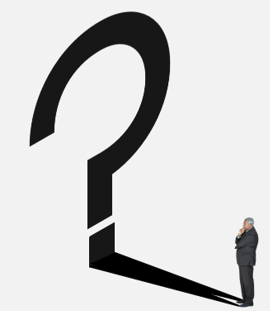

## **Assignment #2**: Code a MC Dropout-based version of ResNet18

In [8]:
class ResNetMC(tf.keras.Model):

    def __init__(self, num_classes=10, mc_dropout=None):
        super(ResNetMC, self).__init__()
        self.mc_dropout = mc_dropout
        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlock(64, 2, downscale=False)
        self.block_c = ResnetBlock(128, 2)
        self.block_d = ResnetBlock(256, 2)
        self.block_e = ResnetBlock(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

        self.drop1 = tf.keras.layers.Dropout(rate=mc_dropout)
        self.drop2 = tf.keras.layers.Dropout(rate=mc_dropout)
        self.drop3 = tf.keras.layers.Dropout(rate=mc_dropout)
        self.drop4 = tf.keras.layers.Dropout(rate=mc_dropout)
        self.drop5 = tf.keras.layers.Dropout(rate=mc_dropout)

    def call(self, inputs):
        x = self.block_a(inputs)
        if self.mc_dropout:
            x = self.drop1(x)
        x = self.block_b(x)
        if self.mc_dropout:
            x = self.drop2(x)
        x = self.block_c(x)
        if self.mc_dropout:
            x = self.drop3(x)
        x = self.block_d(x)
        if self.mc_dropout:
            x = self.drop4(x)
        x = self.block_e(x)
        if self.mc_dropout:
            x = self.drop5(x)
        x = self.global_pool(x)
        return self.classifier(x)

## Load EMNIST

In [9]:
def show_images_from_npy(array, cmap=None):
    fig, ax = plt.subplots(1, 5)
    ax = ax.ravel()
    j = 0
    for idx in np.random.randint(0, array.shape[0], 5):
        ax[j].imshow(array[idx], cmap=cmap)
        ax[j].axis('off')
        j += 1
emnist = np.load(os.path.join(ROOTDIR_DATA, "emnist_images.npy"))
emnist_numpy = (emnist / 255).astype(np.float32)

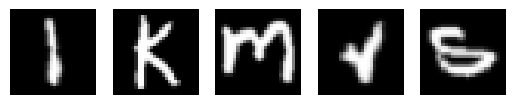

In [10]:
show_images_from_npy(emnist_numpy, cmap="gray")

N.B. Do not shuffle emnist

In [11]:

emnist = np.load(os.path.join(ROOTDIR_DATA, "emnist_images.npy"))
emnist_numpy = (emnist / 255).astype(np.float32)


In [12]:
preds_emnist = net.predict(emnist_numpy)

313/313 [==============================] - 3s 8ms/step


## **Assignment #3**: Code a wrapper for a MC-based network
Implements:
1.   Several metrics to compute uncertainty
2.   Method to reierate predictions


In [13]:
class UncertaintyWrapper(tf.keras.Model):

    def __init__(self, num_classes=10, mc_dropout=None):
        super(UncertaintyWrapper, self).__init__()
        print(f"MC Dropout is set to {mc_dropout}")
        self.model = ResNetMC(mc_dropout=mc_dropout)
        self._uncertainty_metrics = dict()
        self._uncertainty_metrics['entropy'] = self._entropy
        self._uncertainty_metrics['variance'] = self._variance
        self._uncertainty_metrics['max_softmax_response'] = self._max_softmax_response

    def call(self, inputs):
        return self.model(inputs)

    def uncertainty_metrics(self, multiple_preds):
        return {metric: self._compute_uncertainty(
            metric,
            multiple_preds) for metric in self._uncertainty_metrics.keys()}

    def _normalize(self, values):
            return (values - values.min())/(values.max()-values.min())

    def _compute_uncertainty(self, metric, multiple_preds):
        try:
            print("Done {}".format(metric))
            return self._normalize(
                self._uncertainty_metrics[metric](multiple_preds))
        except KeyError:
            print("{} not implemented.".format(metric))

    def predict_many_times(self, inputs, draws=2):
        preds = []

        for _ in range(draws):
            if isinstance(inputs, tf.data.Dataset):
                batch_preds = []
                for batch in inputs:
                    x = batch[0]
                    pred = self.model(x, training=False)
                    batch_preds.append(pred.numpy())
                preds.append(np.concatenate(batch_preds, axis=0))
            else:
                pred = self.model(inputs, training=False)
                preds.append(pred.numpy())

        return np.stack(preds, axis=0)
    
    def _avreage_prediction(self, multiple_preds):
        return np.mean(multiple_preds, axis=0)

    def _entropy(self, multiple_preds):
        avg_preds = self._avreage_prediction(multiple_preds)
        eps = 1e-5
        entropy = -1 * np.sum(avg_preds * np.log(avg_preds + eps), axis=1)
        return entropy

    def _variance(self, multiple_preds):
        return np.mean(np.var(multiple_preds, axis=0), axis=1)

    def _max_softmax_response(self, multiple_preds):
        avg_preds = self._avreage_prediction(multiple_preds)
        return 1 - np.max(avg_preds, axis=1)

In [14]:
net_unc = UncertaintyWrapper(mc_dropout=0.1)
net_unc.build((1, 28, 28, 1))
net_unc.summary()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
net_unc.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
net_unc.fit(mnist_train, epochs=1)
print("Accuracy on test set: {:.2f}".format(net_unc.evaluate(mnist_test)[1]))

MC Dropout is set to 0.1
Model: "uncertainty_wrapper"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 res_net_mc (ResNetMC)       multiple                  11186186  
                                                                 
Total params: 11,186,186
Trainable params: 11,178,378
Non-trainable params: 7,808
_________________________________________________________________
79/79 [==============================] - 1s 9ms/step - loss: 0.1427 - accuracy: 0.9558
Accuracy on test set: 0.96


## Compute MC predicitons and compare with *deterministic* uncertainty computation

In [15]:
multiple_preds_emnist = net_unc.predict_many_times(emnist, draws=10)
multiple_preds_mnist = net_unc.predict_many_times(mnist_test, draws=10)

In [16]:
uncertainties = {}
uncertainties_deterministic = {}

uncertainties['mnist'] = net_unc.uncertainty_metrics(multiple_preds_mnist)
uncertainties['emnist'] = net_unc.uncertainty_metrics(multiple_preds_emnist)

uncertainties_deterministic['mnist'] = net_unc.uncertainty_metrics(
    np.expand_dims(preds_mnist, axis=0)
)
uncertainties_deterministic['emnist'] = net_unc.uncertainty_metrics(
    np.expand_dims(preds_emnist, axis=0)
)


Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response


C:\Users\dorot\AppData\Local\Temp\ipykernel_219296\3375280346.py:21: RuntimeWarning: invalid value encountered in divide
  return (values - values.min())/(values.max()-values.min())


## **Assignment #4** Uncertainty metrics distributions for MNIST and EMNIST
Plot distributions in form of histograms


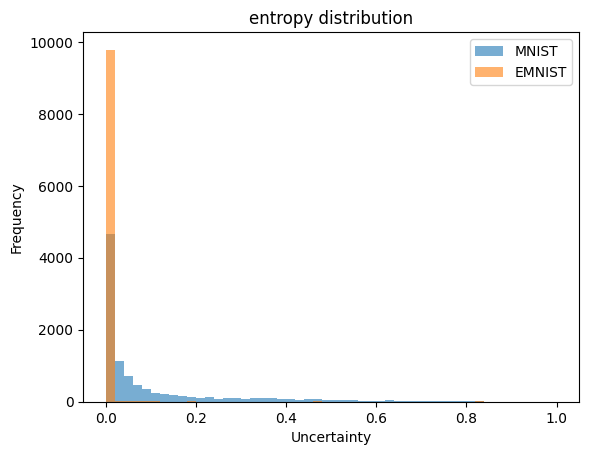

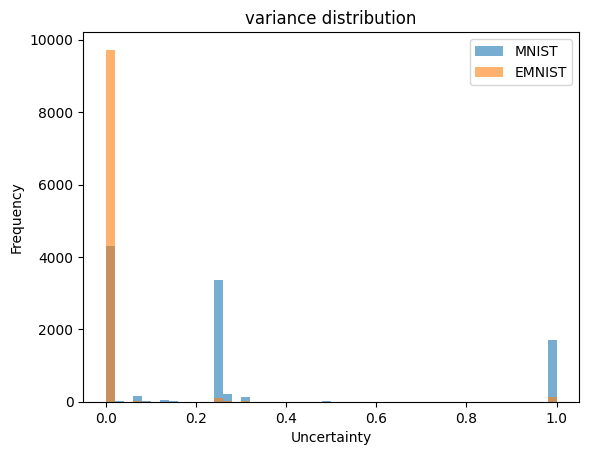

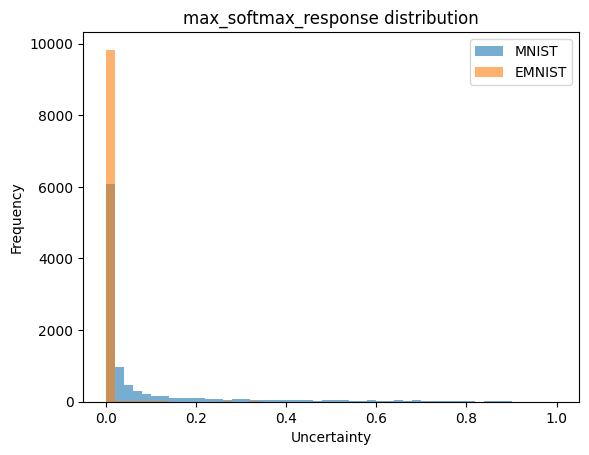

In [17]:
import matplotlib.pyplot as plt

metrics = ['entropy', 'variance', 'max_softmax_response']

for metric in metrics:
    plt.figure()
    
    plt.hist(uncertainties['mnist'][metric], bins=50, alpha=0.6, label='MNIST')
    plt.hist(uncertainties['emnist'][metric], bins=50, alpha=0.6, label='EMNIST')
    
    plt.title(f"{metric} distribution")
    plt.legend()
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
    
    plt.show()

## **Assignment #5** Take a look at confident and not-confident predictions for EMNIST
Filter confident and not-confident images based on uncertainty values and plot some of them

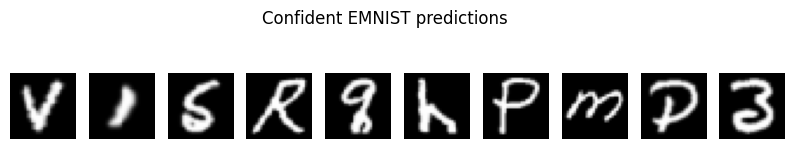

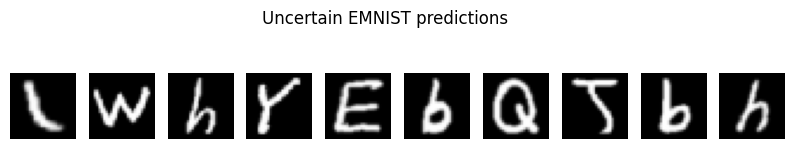

In [21]:
unc = uncertainties['emnist']['entropy']
sorted_idx = np.argsort(unc)
confident_idx = sorted_idx[:10]
uncertain_idx = sorted_idx[-10:]

images = emnist_numpy  

def plot_images(indices, title):
    plt.figure(figsize=(10, 2))
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices), i + 1)
        plt.imshow(images[idx].squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

plot_images(confident_idx, "Confident EMNIST predictions")
plot_images(uncertain_idx, "Uncertain EMNIST predictions")


# **Assignment #6** Uncertainty in DL - Ensamble
Populate a list of ResNet18 classifiers to create a group of expert (ignore indipendancy among datasets, i.e. different training cohorts).

In [25]:
nets = list()
for _ in range(3):
    net = ResNet()
    net.build((1, 28, 28, 1))
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
    net.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics="accuracy")
    net.fit(mnist_train, epochs=3)
    nets.append(net)

Epoch 1/3
469/469 [==============================] - 18s 34ms/step - loss: 0.1316 - accuracy: 0.9589
Epoch 2/3
469/469 [==============================] - 12s 26ms/step - loss: 0.0363 - accuracy: 0.9887
Epoch 3/3
469/469 [==============================] - 13s 27ms/step - loss: 0.0178 - accuracy: 0.9946
Epoch 1/3
469/469 [==============================] - 14s 27ms/step - loss: 0.1373 - accuracy: 0.9571
Epoch 2/3
469/469 [==============================] - 14s 30ms/step - loss: 0.0336 - accuracy: 0.9893
Epoch 3/3
469/469 [==============================] - 17s 36ms/step - loss: 0.0149 - accuracy: 0.9956
Epoch 1/3
469/469 [==============================] - 16s 29ms/step - loss: 0.1344 - accuracy: 0.9583
Epoch 2/3
469/469 [==============================] - 12s 26ms/step - loss: 0.0331 - accuracy: 0.9897
Epoch 3/3
469/469 [==============================] - 12s 27ms/step - loss: 0.0174 - accuracy: 0.9947


In [40]:
emnist_preds_ensamble = []
mnist_preds_ensamble = []
for net in nets:
    emnist_preds_ensamble.append(net.predict(emnist))
    mnist_preds_ensamble.append(net.predict(mnist_test))


79/79 [==============================] - 1s 9ms/step


In [44]:
uncertainties_ensable = dict()
uncertainties_ensable['mnist']  = net_unc.uncertainty_metrics(np.array(mnist_preds_ensamble))
uncertainties_ensable['emnist'] = net_unc.uncertainty_metrics(np.array(emnist_preds_ensamble))

preds_mnist  = net.predict(mnist_test)
preds_emnist = net.predict(emnist)

uncertainties_deterministic = dict()
uncertainties_deterministic['mnist']  = net_unc.uncertainty_metrics(np.expand_dims(preds_mnist, axis=0))
uncertainties_deterministic['emnist'] = net_unc.uncertainty_metrics(np.expand_dims(preds_emnist, axis=0))

for measure in uncertainties_deterministic['mnist']:
    uncertainties_deterministic['mnist'][measure]  = np.nan_to_num(uncertainties_deterministic['mnist'][measure],  nan=0.0)
    uncertainties_deterministic['emnist'][measure] = np.nan_to_num(uncertainties_deterministic['emnist'][measure], nan=0.0)

Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response
313/313 [==============================] - 3s 9ms/step
Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response


C:\Users\dorot\AppData\Local\Temp\ipykernel_219296\3375280346.py:21: RuntimeWarning: invalid value encountered in divide
  return (values - values.min())/(values.max()-values.min())


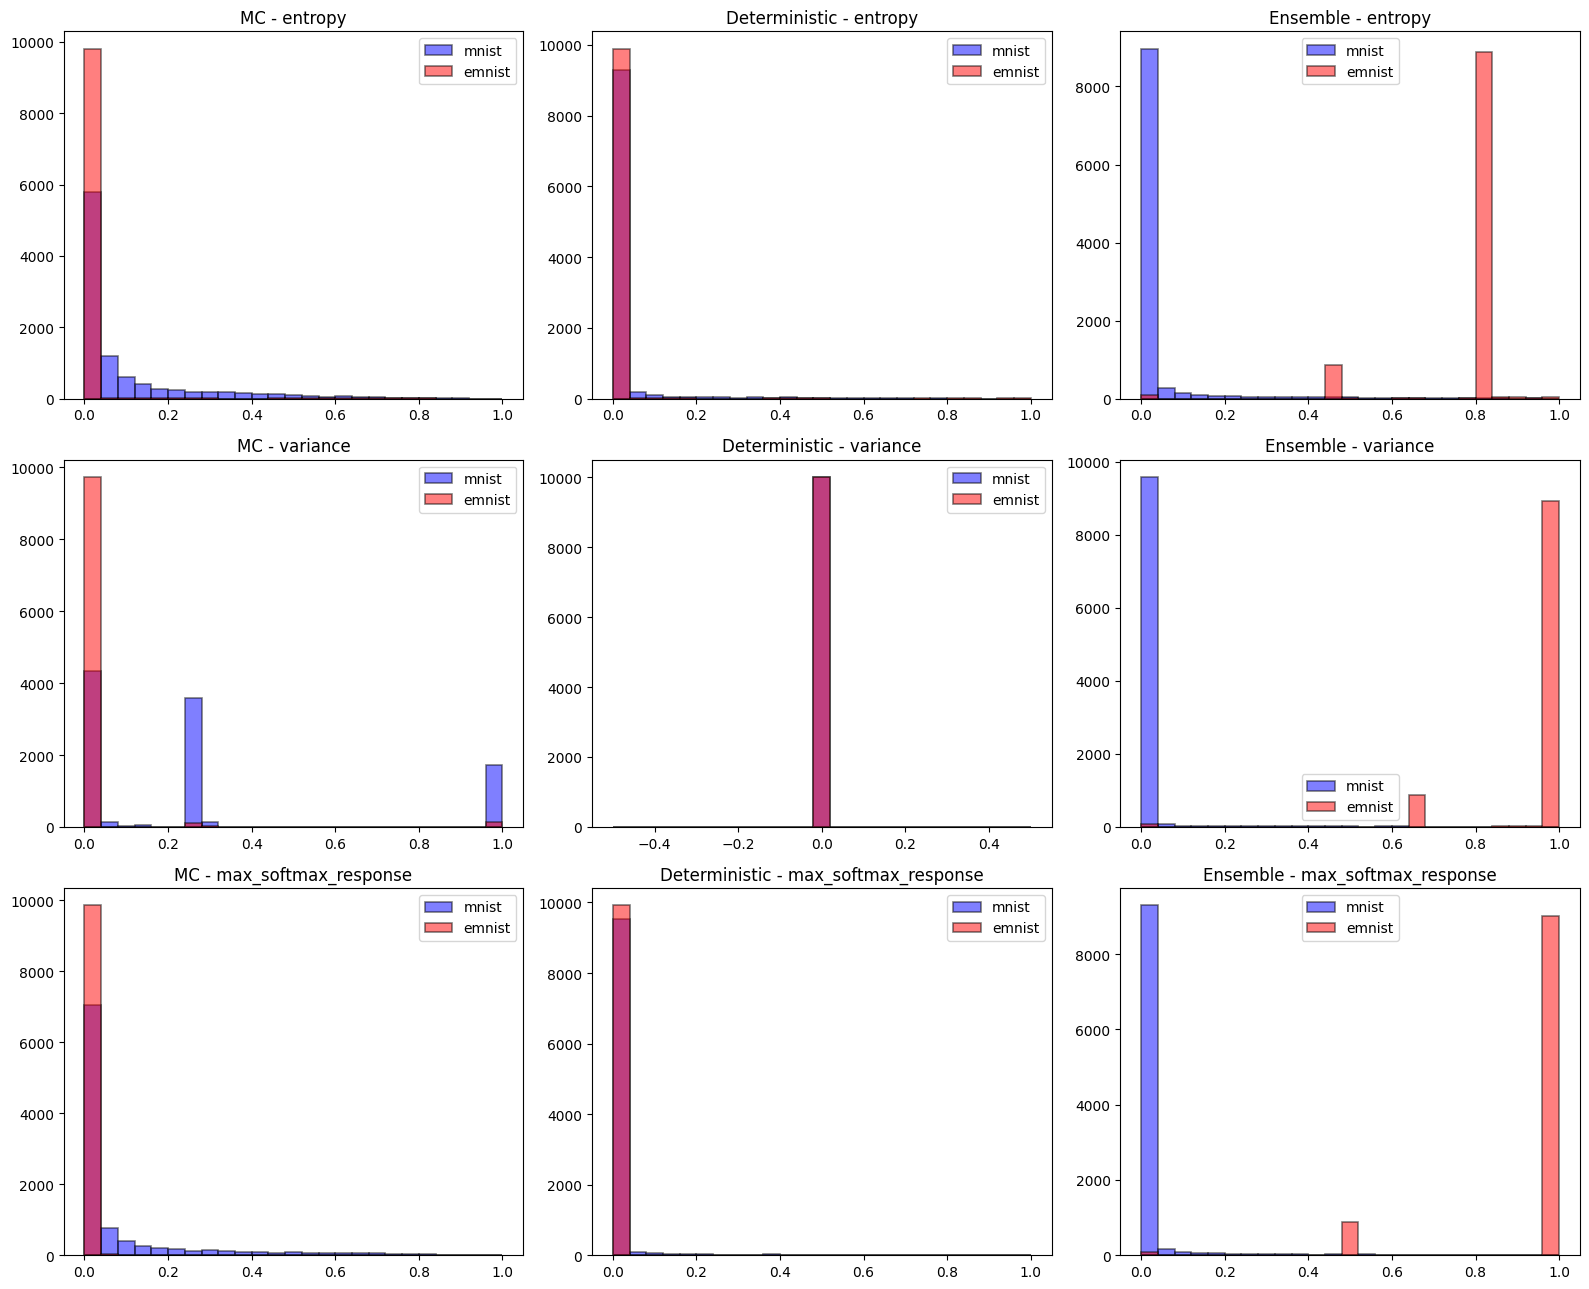

In [45]:
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 3, figsize=(16, 13))
for ax, measure in zip(axes, net_unc._uncertainty_metrics.keys()):
    ax[0].set_title(f"MC - {measure}")
    ax[0].hist(uncertainties['mnist'][measure], color="blue", bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist")
    ax[0].hist(uncertainties['emnist'][measure], color="red", bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist")
    ax[0].legend()

    ax[1].set_title(f"Deterministic - {measure}")
    ax[1].hist(uncertainties_deterministic['mnist'][measure], color="blue", bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist")
    ax[1].hist(uncertainties_deterministic['emnist'][measure], color="red", bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist")
    ax[1].legend()

    ax[2].set_title(f"Ensemble - {measure}")
    ax[2].hist(uncertainties_ensable['mnist'][measure], color="blue", bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist")
    ax[2].hist(uncertainties_ensable['emnist'][measure], color="red", bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist")
    ax[2].legend()

plt.tight_layout()

In [48]:
import tensorflow_probability as tfp
#
tfd = tfp.distributions
NUM_TRAIN_EXAMPLES = 50000
NUM_CLASSES = 10
LR = 0.01

# Uncertainty in DL - Variational Inference

In [49]:
class ResidualVI(tf.keras.Model):
    """The Residual block of ResNet."""

    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.kl_divergence_function = (lambda q, p, _: tfd.kl_divergence(q, p) /
                                       tf.cast(NUM_TRAIN_EXAMPLES, dtype=tf.float32))
        self.conv1 = tfp.layers.Convolution2DFlipout(
            num_channels,
            kernel_size=3,
            padding='same',
            strides=strides,
            kernel_divergence_fn=self.kl_divergence_function,
            activation=tf.nn.relu)
        self.conv2 = tfp.layers.Convolution2DFlipout(
            num_channels,
            kernel_size=3,
            padding='same',
            kernel_divergence_fn=self.kl_divergence_function,
            activation=tf.nn.relu)
        self.conv_1x1 = None
        if use_1x1conv:
            self.conv_1x1 = tf.keras.layers.Conv2D(
                num_channels,
                kernel_size=1,
                strides=strides)

            self.conv_1x1 = tfp.layers.Convolution2DFlipout(
                num_channels,
                kernel_size=1,
                strides=strides,
                kernel_divergence_fn=self.kl_divergence_function)

        self.bn1 = tf.keras.layers.BatchNormalization()
        self.bn2 = tf.keras.layers.BatchNormalization()

    def call(self, X):
        Y = tf.keras.activations.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv_1x1 is not None:
            X = self.conv_1x1(X)
        Y += X
        return tf.keras.activations.relu(Y)

class ResnetBlockVI(tf.keras.layers.Layer):
    def __init__(self, num_channels, num_residuals, downscale=True,
                 **kwargs):
        super(ResnetBlockVI, self).__init__(**kwargs)
        self.residual_layers = []
        for i in range(num_residuals):
            if i == 0 and downscale:
                self.residual_layers.append(
                    ResidualVI(num_channels, use_1x1conv=True, strides=2))
            else:
                self.residual_layers.append(ResidualVI(num_channels))

    def call(self, X):
        for layer in self.residual_layers.layers:
            X = layer(X)
        return X

class ResNetVI(tf.keras.Model):

    def __init__(self, num_classes=10):
        super(ResNetVI, self).__init__()
        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlockVI(64, 2, downscale=False)
        self.block_c = ResnetBlockVI(128, 2)
        self.block_d = ResnetBlockVI(256, 2)
        self.block_e = ResnetBlockVI(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

    def call(self, inputs):
        x = self.block_a(inputs)
        x = self.block_b(x)
        x = self.block_c(x)
        x = self.block_d(x)
        x = self.block_e(x)
        x = self.global_pool(x)
        return self.classifier(x)

In [50]:

class VIWrapper(UncertaintyWrapper):
    def __init__(self, num_classes=10):
        super(VIWrapper, self).__init__()
        self.model = ResNet()
        self._uncertainty_metrics = dict()
        self._uncertainty_metrics['entropy'] = self._entropy
        self._uncertainty_metrics['variance'] = self._variance
        self._uncertainty_metrics['max_softmax_response'] = self._max_softmax_response

        # Replace the last dense layer with a probabilistic one
        self.vi_layer = tfp.layers.DenseFlipout(num_classes, activation='softmax')

    def call(self, inputs):
        x = self.model.block_a(inputs)
        x = self.model.block_b(x)
        x = self.model.block_c(x)
        x = self.model.block_d(x)
        x = self.model.block_e(x)
        x = self.model.global_pool(x)
        return self.vi_layer(x)  # stochastic layer instead of deterministic classifier

    def predict_many_times(self, ds, T=30):
        return [self.predict(ds) for _ in range(T)]

In [51]:
net_vi = VIWrapper()
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
# The Keras API will automatically add the
# Kullback-Leibler divergence (contained on the individual layers of
# the model), to the cross entropy loss, effectively
# calcuating the (negated) Evidence Lower Bound Loss (ELBO)
net_vi.compile(optimizer, loss='categorical_crossentropy',
               metrics=['accuracy'], experimental_run_tf_function=False)

MC Dropout is set to None


In [52]:
net_vi.fit(mnist_train, epochs=3)

Epoch 1/3


c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\.venv\lib\site-packages\tensorflow_probability\python\layers\util.py:95: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
c:\Users\dorot\OneDrive - Politecnico di Torino\Desktop\ML in Application\LABS\Labs-FP\.venv\lib\site-packages\tensorflow_probability\python\layers\util.py:105: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


469/469 [==============================] - 23s 42ms/step - loss: 4169.2261 - accuracy: 0.3708
Epoch 2/3
469/469 [==============================] - 18s 38ms/step - loss: 5.2565 - accuracy: 0.1112
Epoch 3/3
469/469 [==============================] - 14s 29ms/step - loss: 2.3019 - accuracy: 0.1116


In [54]:
print("Accuracy on test set: {:.2f}".format(net_vi.evaluate(mnist_test)[1]))
preds_mnist = net_vi.predict(mnist_test)

79/79 [==============================] - 1s 14ms/step - loss: 2.3012 - accuracy: 0.1135
Accuracy on test set: 0.11
79/79 [==============================] - 1s 9ms/step


In [56]:
vi_preds_emnist = net_vi.predict_many_times(emnist, T=10)
vi_preds_mnist = net_vi.predict_many_times(mnist_test, T=10)

79/79 [==============================] - 1s 8ms/step


In [59]:
uncertainties_vi = dict()
uncertainties_vi['mnist'] = net_unc.uncertainty_metrics(np.array(vi_preds_mnist))
uncertainties_vi['emnist'] = net_unc.uncertainty_metrics(np.array(vi_preds_emnist))

for measure in uncertainties_vi['mnist']:
    uncertainties_vi['mnist'][measure]  = np.nan_to_num(uncertainties_vi['mnist'][measure],  nan=0.0)
    uncertainties_vi['emnist'][measure] = np.nan_to_num(uncertainties_vi['emnist'][measure], nan=0.0)



Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response


C:\Users\dorot\AppData\Local\Temp\ipykernel_219296\3375280346.py:21: RuntimeWarning: invalid value encountered in divide
  return (values - values.min())/(values.max()-values.min())


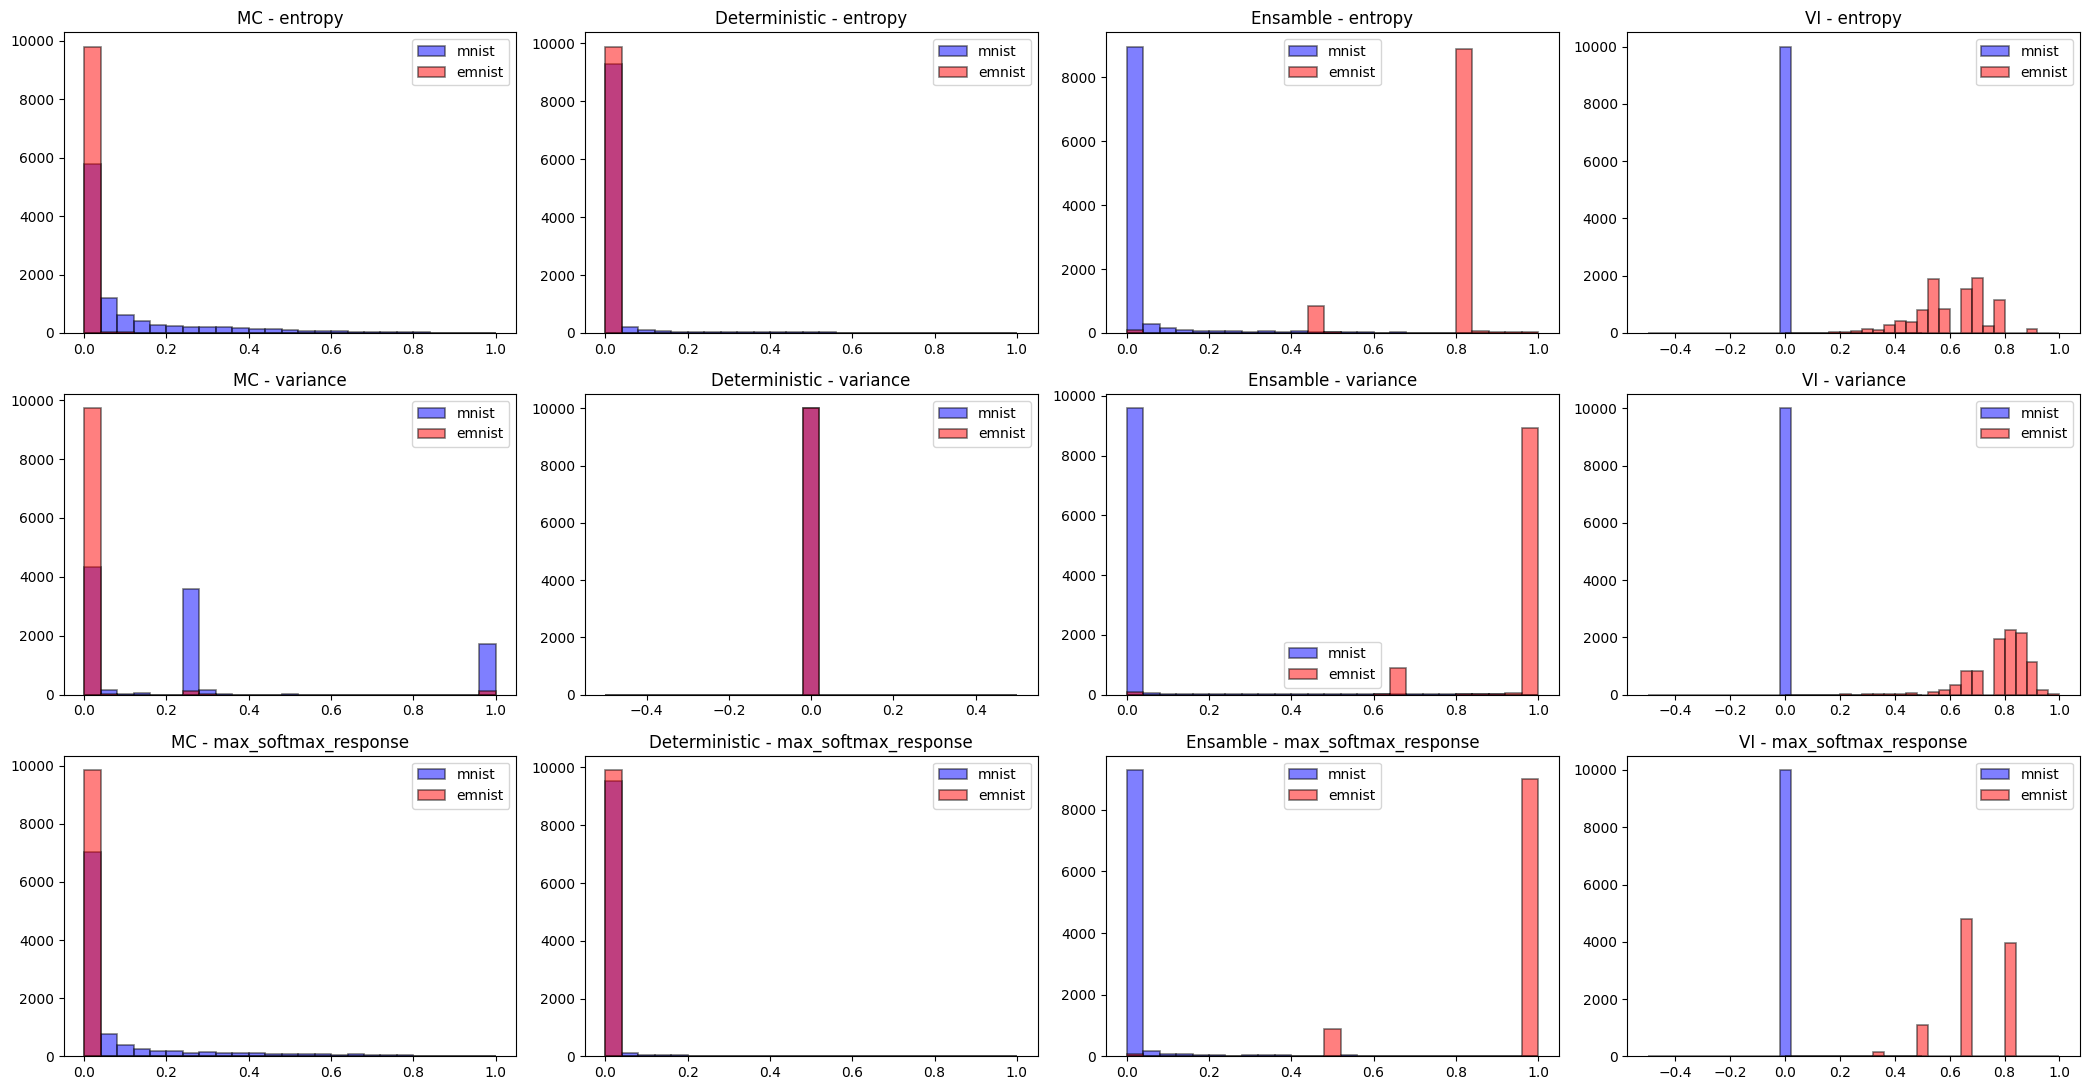

In [60]:
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 4, figsize=(21, 11))
for ax, measure in zip(axes, net_unc._uncertainty_metrics.keys()):
    ax[0] .set_title(f"MC - {measure}")
    ax[0].hist(uncertainties['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[0].hist(uncertainties['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[0].legend()
    ax[1] .set_title(f"Deterministic - {measure}")
    ax[1].hist(uncertainties_deterministic['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[1].hist(uncertainties_deterministic['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[1].legend()
    ax[2] .set_title(f"Ensamble - {measure}")
    ax[2].hist(uncertainties_ensable['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[2].hist(uncertainties_ensable['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[2].legend()
    ax[3] .set_title(f"VI - {measure}")
    ax[3].hist(uncertainties_vi['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[3].hist(uncertainties_vi['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[3].legend()
plt.tight_layout()

# **Assignment #7** Uncertainty in DL - Test Time Augmentation-Based
See [data augmentation for tensorflow and keras](https://www.tensorflow.org/tutorials/images/data_augmentation) to implement some data augmentation techniques.

In [61]:
class TTAWrapper(UncertaintyWrapper):
    def __init__(self, num_classes=10):
        super(TTAWrapper, self).__init__()
        self.model = ResNet()
        self._uncertainty_metrics = dict()
        self._uncertainty_metrics['entropy'] = self._entropy
        self._uncertainty_metrics['variance'] = self._variance
        self._uncertainty_metrics['max_softmax_response'] = self._max_softmax_response

    def call(self, inputs):
        return self.model(inputs)

    def predict_many_times(self, ds, policy, repeat=1):
        pred_augmented = list()

        policy_identity = [tf.keras.Sequential([
            tf.keras.layers.Layer()])]

        policy_random_crop = [tf.keras.Sequential([
            tf.keras.layers.ZeroPadding2D(padding=2),
            tf.keras.layers.RandomCrop(28, 28)])]

        policy_random_flip = [tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal")])]

        policy_random_contrast = [tf.keras.Sequential([
            tf.keras.layers.RandomContrast(factor=0.2)])]

        policy_random_zoom = [tf.keras.Sequential([
            tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1)])]

        policies = dict()
        policies['identity'] = policy_identity
        policies['random_crop'] = policy_random_crop
        policies['random_contrast'] = policy_random_contrast
        policies['random_zoom'] = policy_random_zoom
        policies['random_flip'] = policy_random_flip

        policies['random_crop']     = sum([policies['random_crop']     for _ in range(repeat)], [])
        policies['random_contrast'] = sum([policies['random_contrast'] for _ in range(repeat)], [])
        policies['random_zoom']     = sum([policies['random_zoom']     for _ in range(repeat)], [])
        policies['random_flip']     = sum([policies['random_flip']     for _ in range(repeat)], [])

        for p in policies[policy]:
            ds_augmented = ds.map(lambda x, y: (p(x, training=True), y))
            pred_augmented.append(self.predict(ds_augmented))

        return pred_augmented

In [62]:
net_tta = TTAWrapper()
net_tta.build((1, 28, 28, 1))
net_tta.summary()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
net_tta.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics="accuracy")
net_tta.fit(mnist_train, epochs=3)
print("Accuracy on test set: {:.2f}".format(net_tta.evaluate(mnist_test)[1]))

MC Dropout is set to None
Model: "tta_wrapper"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 res_net_8 (ResNet)          multiple                  11186186  
                                                                 
Total params: 11,186,186
Trainable params: 11,178,378
Non-trainable params: 7,808
_________________________________________________________________
Epoch 1/3
469/469 [==============================] - 21s 40ms/step - loss: 0.1308 - accuracy: 0.9604
Epoch 2/3
469/469 [==============================] - 17s 35ms/step - loss: 0.0349 - accuracy: 0.9888
Epoch 3/3
79/79 [==============================] - 1s 10ms/step - loss: 0.0370 - accuracy: 0.9874
Accuracy on test set: 0.99


In [66]:
dummy_labels = np.zeros(len(emnist))
emnist_ds = tf.data.Dataset.from_tensor_slices((emnist, dummy_labels))
emnist_ds = emnist_ds.batch(128).prefetch(tf.data.AUTOTUNE)

emnist_preds_tta = net_tta.predict_many_times(emnist_ds, "random_zoom", repeat=10)
mnist_preds_tta  = net_tta.predict_many_times(mnist_test, "random_zoom", repeat=10)

79/79 [==============================] - 1s 9ms/step


79/79 [==============================] - 7s 82ms/step


79/79 [==============================] - 7s 79ms/step


79/79 [==============================] - 7s 85ms/step


79/79 [==============================] - 7s 82ms/step


...

79/79 [==============================] - 7s 86ms/step


79/79 [==============================] - 7s 85ms/step


79/79 [==============================] - 6s 69ms/step


79/79 [==============================] - 6s 71ms/step


79/79 [==============================] - 7s 77ms/step


Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response


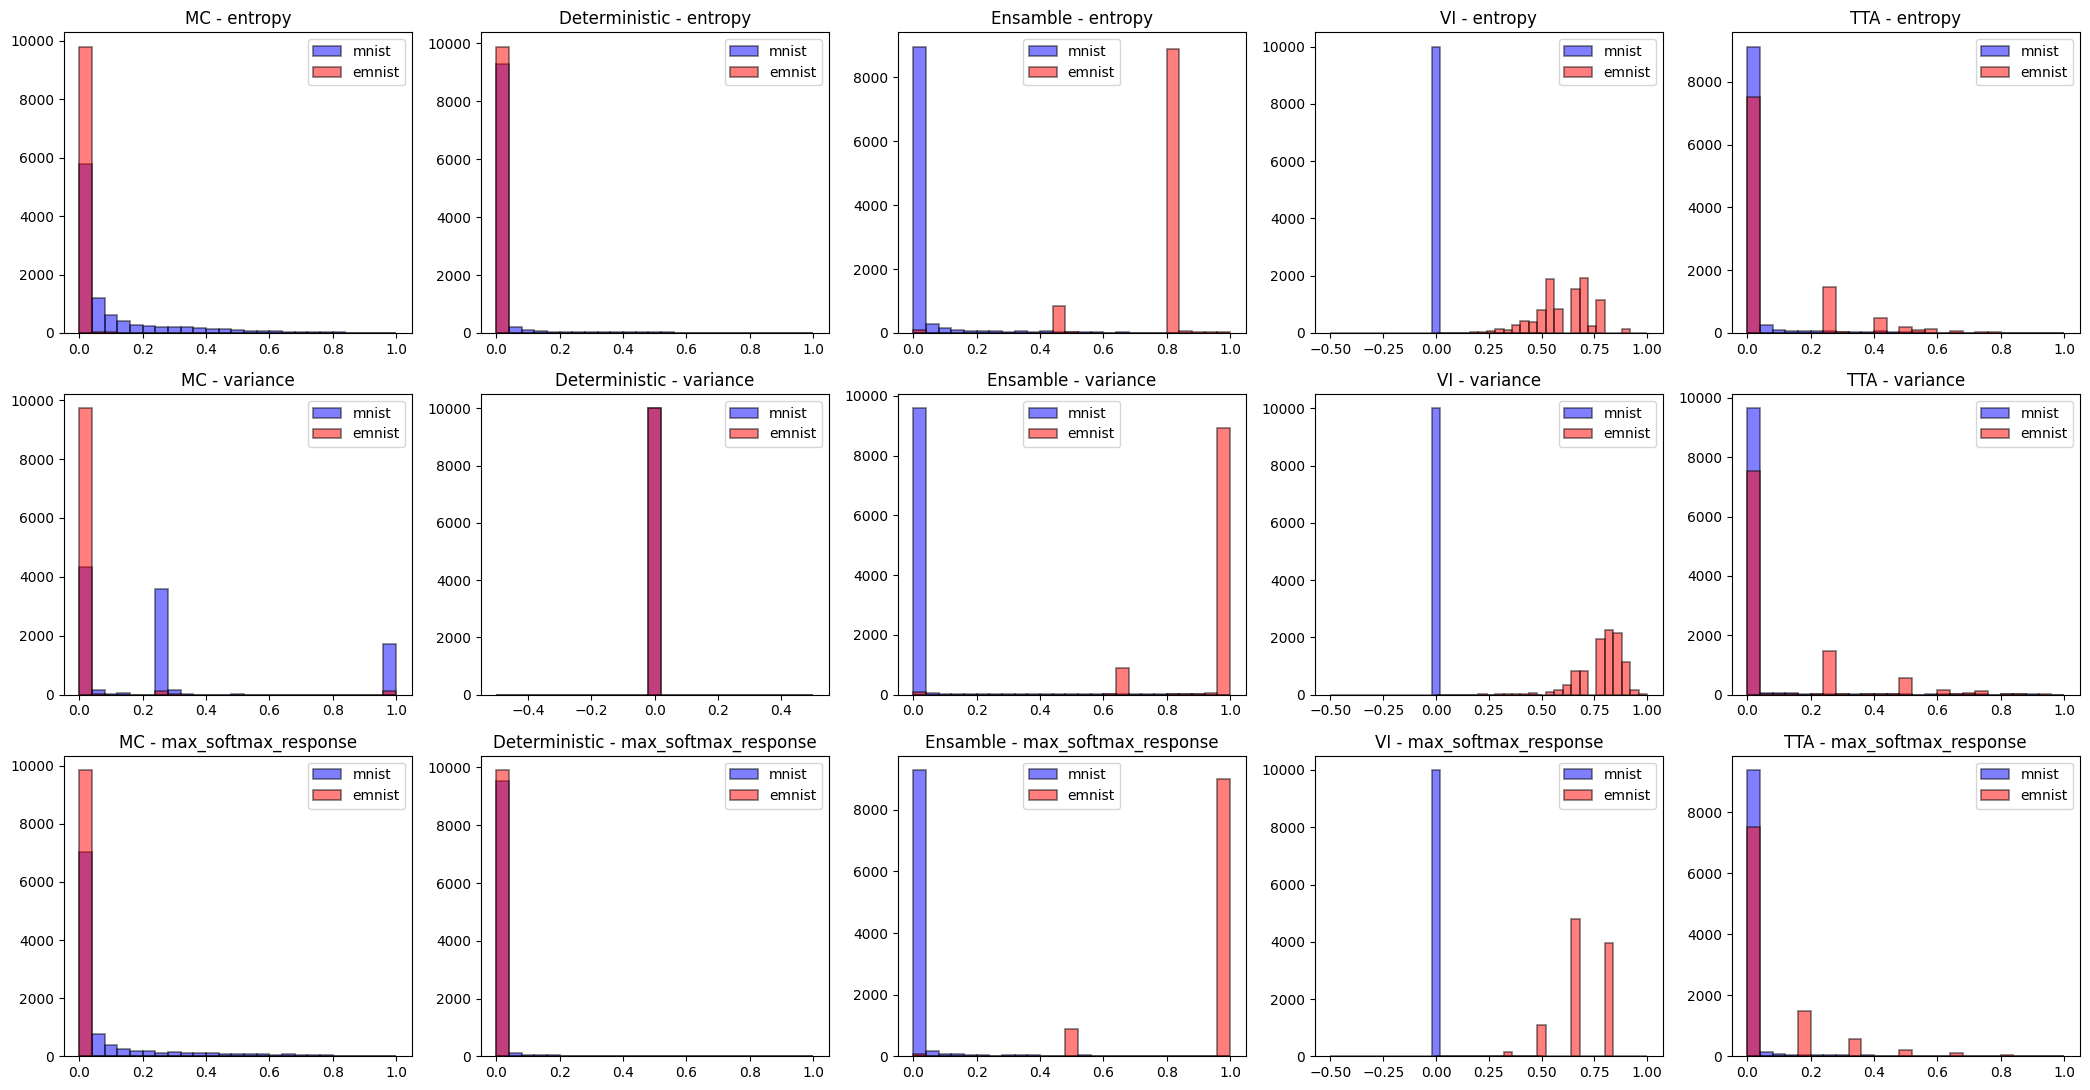

In [67]:
uncertainties_tta = dict()
uncertainties_tta['mnist'] = net_tta.uncertainty_metrics(np.array(mnist_preds_tta))
uncertainties_tta['emnist'] = net_tta.uncertainty_metrics(np.array(emnist_preds_tta))
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 5, figsize=(21, 11))
for ax, measure in zip(axes, net_unc._uncertainty_metrics.keys()):
    ax[0].set_title(f"MC - {measure}")
    ax[0].hist(uncertainties['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[0].hist(uncertainties['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[0].legend()
    ax[1].set_title(f"Deterministic - {measure}")
    ax[1].hist(uncertainties_deterministic['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[1].hist(uncertainties_deterministic['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[1].legend()
    ax[2].set_title(f"Ensamble - {measure}")
    ax[2].hist(uncertainties_ensable['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[2].hist(uncertainties_ensable['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[2].legend()
    ax[3].set_title(f"VI - {measure}")
    ax[3].hist(uncertainties_vi['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[3].hist(uncertainties_vi['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[3].legend()
    ax[4].set_title(f"TTA - {measure}")
    ax[4].hist(uncertainties_tta['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[4].hist(uncertainties_tta['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[4].legend()
plt.tight_layout()